<a href="https://colab.research.google.com/github/mail2chandanadasari-code/ML_LAB_2026-27/blob/main/Linear_regression_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

# Load a real dataset from a public URL
url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"
df = pd.read_csv(url)

df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [5]:
# Separate predictors (X) and target variable (y)
X = df.drop(columns=['medv'])
y = df['medv']

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [8]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [9]:
y_pred = model.predict(X_test)

In [10]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Squared Error: 24.291119474973478
R2 Score: 0.6687594935356326


In [11]:
import matplotlib.pyplot as plt

# Sort feature values for clean line plotting (using 'rm' room count as example feature)
X_test_sorted = X_test.sort_values(by='rm')
y_pred_sorted = model.predict(X_test_sorted)

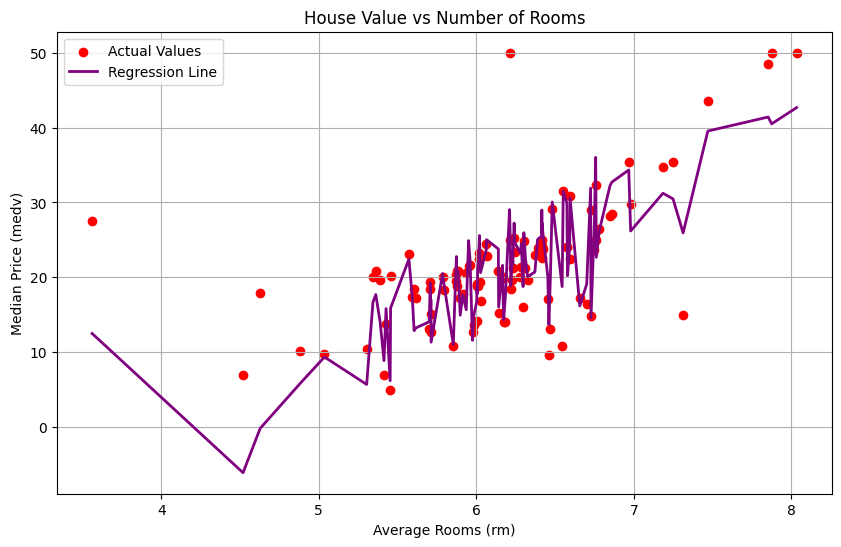

In [12]:
plt.figure(figsize=(10, 6))

plt.scatter(X_test['rm'], y_test, color='red', label='Actual Values')
plt.plot(X_test_sorted['rm'], y_pred_sorted, color='purple', linewidth=2, label='Regression Line')

plt.title("House Value vs Number of Rooms")
plt.xlabel("Average Rooms (rm)")
plt.ylabel("Median Price (medv)")
plt.legend()
plt.grid(True)
plt.show()